In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Load data
df = pd.read_csv('/content/Crimes_-_2001_to_Present_20251023.csv')

# Drop rows without coordinates
df = df.dropna(subset=['Latitude', 'Longitude'])

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']),
    crs="EPSG:4326"
)


In [ ]:
import geopandas as gpd

# Replace path with your downloaded file
communities = gpd.read_file("/content/Boundaries_-_Community_Areas_20251023.geojson")


In [ ]:
# Ensure both have same CRS
gdf = gdf.set_crs("EPSG:4326")
communities = communities.to_crs("EPSG:4326")

# Spatial join
gdf_joined = gpd.sjoin(gdf, communities, how="inner", predicate="within")


In [ ]:
import plotly.express as px
import pandas as pd

# Top 10 crime types
top10 = gdf_joined["Primary Type"].value_counts().nlargest(10).index
subset = gdf_joined[gdf_joined["Primary Type"].isin(top10)].copy()

# Relabel booleans for readability
subset["Arrest Label"] = subset["Arrest"].map({True: "Arrested", False: "Not Arrested"})
subset["Domestic Label"] = subset["Domestic"].map({True: "Domestic", False: "Not Domestic"})

# Sunburst chart
fig = px.sunburst(
    subset,
    path=["Primary Type", "Arrest Label", "Domestic Label"],
    values="ID",
    color="Primary Type",
    title="Hierarchical Breakdown: Crime Type → Arrest Status → Domestic Context",
    color_discrete_sequence=px.colors.qualitative.Set3
)

# Improve text readability
fig.update_traces(textinfo="label+percent parent")
fig.update_layout(
    margin=dict(t=60, l=0, r=0, b=0),
    title_font=dict(size=20, family="Arial", color="#333")
)

fig.show()


## Dendogram

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Style configuration
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


In [ ]:
# Data Loading and Preparation

df = pd.read_csv('Crimes.csv')

# Load Community Areas GeoJSON (make sure to upload this file too)
communities = gpd.read_file("/content/Boundaries_-_Community_Areas_20251023.geojson")

# Data cleaning and preparation
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])
cutoff_date = pd.Timestamp('2025-07-31')
df = df[df['Date'] <= cutoff_date]
df = df.sort_values('Date')

# Add temporal features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

print(f" Data loaded successfully")
print(f" Period: {df['Date'].min().strftime('%Y-%m')} to {df['Date'].max().strftime('%Y-%m')}")
print(f" Total crimes: {len(df):,}")
print(f" Community areas geometry: {len(communities)} areas")

 Data loaded successfully
 Period: 2020-01 to 2025-07
 Total crimes: 1,321,175
 Community areas geometry: 77 areas


In [ ]:
#  Data Preparation for Clustering
print(" PREPARING DATA FOR CLUSTERING ANALYSIS")

# Create GeoDataFrame for spatial join
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.Longitude, df.Latitude),
    crs="EPSG:4326"
)

# Ensure both have the same CRS
communities = communities.to_crs("EPSG:4326")

# Perform spatial join
gdf_joined = gpd.sjoin(gdf, communities, how="inner", predicate="within")

print(f" Spatial join completed")
print(f" Crimes with location data: {len(gdf_joined):,}")
print(f" Unique community areas: {gdf_joined['community'].nunique()}")

 PREPARING DATA FOR CLUSTERING ANALYSIS
 Spatial join completed
 Crimes with location data: 1,297,557
 Unique community areas: 77



HIERARCHICAL CLUSTERING ANALYSIS - COMMUNITY AREAS
Preparing clustering data...
Performing hierarchical clustering...
Using manual threshold: 8.00

 Threshold exploration:
  Threshold 8.0 → 5 clusters
  Threshold 10.0 → 4 clusters
  Threshold 12.0 → 4 clusters
  Threshold 15.0 → 2 clusters
  Threshold 18.0 → 2 clusters
  Threshold 20.0 → 2 clusters

Selected: Threshold 8.0 → 5 clusters


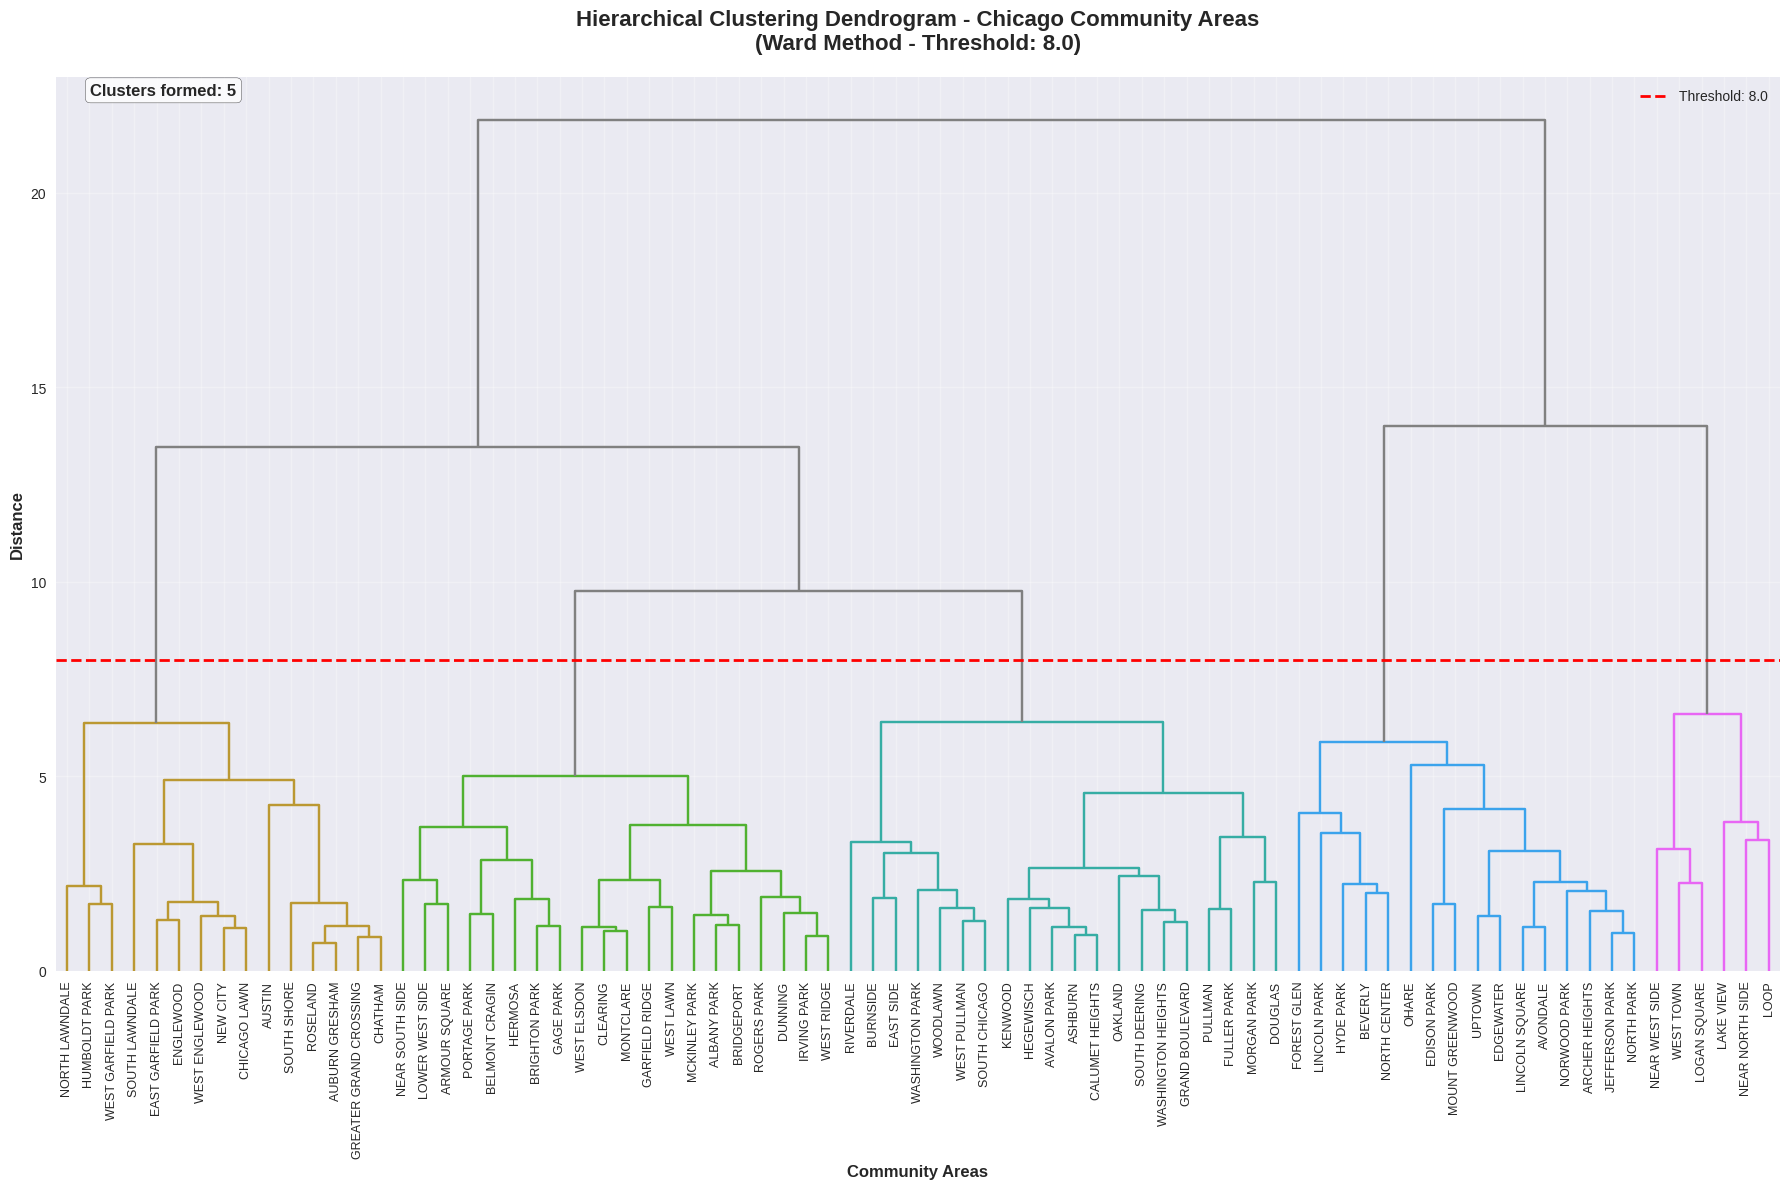


 CLUSTER INFORMATION:
Threshold used: 8.00
Number of clusters formed: 5

COMMUNITIES BY CLUSTER:

Cluster 1 (15 communities, 488,496 total crimes):
  HUMBOLDT PARK, AUSTIN, NEW CITY, GREATER GRAND CROSSING, SOUTH SHORE, NORTH LAWNDALE, EAST GARFIELD PARK, ROSELAND
  ... and 7 more communities

Cluster 2 (20 communities, 222,643 total crimes):
  PORTAGE PARK, LOWER WEST SIDE, ROGERS PARK, BRIGHTON PARK, BELMONT CRAGIN, GARFIELD RIDGE, IRVING PARK, CLEARING
  ... and 12 more communities

Cluster 3 (20 communities, 208,718 total crimes):
  MORGAN PARK, WASHINGTON HEIGHTS, WEST PULLMAN, WOODLAWN, BURNSIDE, SOUTH CHICAGO, EAST SIDE, RIVERDALE
  ... and 12 more communities

Cluster 4 (16 communities, 140,031 total crimes):
  UPTOWN, LINCOLN SQUARE, EDISON PARK, LINCOLN PARK, BEVERLY, ARCHER HEIGHTS, MOUNT GREENWOOD, HYDE PARK
  ... and 8 more communities

Cluster 5 (6 communities, 237,669 total crimes):
  WEST TOWN, LOGAN SQUARE, NEAR NORTH SIDE, LAKE VIEW, LOOP, NEAR WEST SIDE


In [ ]:
# Dendrogram - Hierarchical Clustering of Community Areas (Manual Threshold)
print("\n" + "="*70)
print("HIERARCHICAL CLUSTERING ANALYSIS - COMMUNITY AREAS")
print("="*70)


# Prepare data for clustering
print("Preparing clustering data...")

# Create features for each Community Area
clustering_data = []

for community_name in gdf_joined['community'].unique():
    community_data = gdf_joined[gdf_joined['community'] == community_name]

    # Calculate various crime metrics for clustering
    total_crimes = len(community_data)

    # Crime type distribution (top 5 crime types as percentages)
    crime_type_dist = community_data['Primary Type'].value_counts(normalize=True)
    theft_pct = crime_type_dist.get('THEFT', 0)
    battery_pct = crime_type_dist.get('BATTERY', 0)
    criminal_damage_pct = crime_type_dist.get('CRIMINAL DAMAGE', 0)
    assault_pct = crime_type_dist.get('ASSAULT', 0)
    motor_vehicle_theft_pct = crime_type_dist.get('MOTOR VEHICLE THEFT', 0)

    # Temporal patterns
    monthly_pattern = community_data.resample('M', on='Date').size()
    crime_variability = monthly_pattern.std() if len(monthly_pattern) > 1 else 0

    # Arrest rate
    arrest_rate = community_data['Arrest'].mean()

    # Domestic violence rate
    domestic_rate = community_data['Domestic'].mean()

    # Day of week pattern (weekend vs weekday)
    weekend_crimes = community_data[community_data['DayOfWeek'].isin([5, 6])].shape[0]
    weekend_rate = weekend_crimes / total_crimes if total_crimes > 0 else 0

    clustering_data.append({
        'community': community_name,
        'total_crimes': total_crimes,
        'theft_rate': theft_pct,
        'battery_rate': battery_pct,
        'criminal_damage_rate': criminal_damage_pct,
        'assault_rate': assault_pct,
        'motor_vehicle_theft_rate': motor_vehicle_theft_pct,
        'crime_variability': crime_variability,
        'arrest_rate': arrest_rate,
        'domestic_rate': domestic_rate,
        'weekend_rate': weekend_rate
    })

# Convert to DataFrame
clustering_df = pd.DataFrame(clustering_data)

# Select numerical features for clustering
features = [
    'total_crimes',
    'theft_rate',
    'battery_rate',
    'criminal_damage_rate',
    'assault_rate',
    'motor_vehicle_theft_rate',
    'crime_variability',
    'arrest_rate',
    'domestic_rate',
    'weekend_rate'
]

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(clustering_df[features])

# Perform hierarchical clustering using Ward method
print("Performing hierarchical clustering...")
Z = linkage(scaled_features, method='ward')

# MANUAL THRESHOLD -
optimal_threshold = 8.0
print(f"Using manual threshold: {optimal_threshold:.2f}")

# Explore different threshold values
print("\n Threshold exploration:")
test_thresholds = [8, 10, 12, 15, 18, 20]
for threshold in test_thresholds:
    test_clusters = fcluster(Z, threshold, criterion='distance')
    n_clusters = len(set(test_clusters))
    print(f"  Threshold {threshold:.1f} → {n_clusters} clusters")

# Create clusters using the manual threshold
clusters = fcluster(Z, optimal_threshold, criterion='distance')
clustering_df['cluster'] = clusters
unique_clusters = len(set(clusters))

print(f"\nSelected: Threshold {optimal_threshold:.1f} → {unique_clusters} clusters")

# Create dendrogram with threshold line
plt.figure(figsize=(18, 12))
plt.title(f'Hierarchical Clustering Dendrogram - Chicago Community Areas\n(Ward Method - Threshold: {optimal_threshold:.1f})',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Community Areas', fontsize=12, fontweight='bold')
plt.ylabel('Distance', fontsize=12, fontweight='bold')

# Create dendrogram with custom colors for clusters
dendrogram_result = dendrogram(
    Z,
    labels=clustering_df['community'].values,
    leaf_rotation=90,
    leaf_font_size=9,
    orientation='top',
    color_threshold=optimal_threshold,
    above_threshold_color='gray'
)

# Add threshold line
plt.axhline(y=optimal_threshold, color='red', linestyle='--', linewidth=2,
           label=f'Threshold: {optimal_threshold:.1f}')

# Add cluster count annotation
plt.text(0.02, 0.98, f'Clusters formed: {unique_clusters}',
         transform=plt.gca().transAxes, fontsize=12, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display cluster information
print(f"\n CLUSTER INFORMATION:")
print(f"Threshold used: {optimal_threshold:.2f}")
print(f"Number of clusters formed: {unique_clusters}")

# Show communities in each cluster
print(f"\nCOMMUNITIES BY CLUSTER:")
for cluster_num in sorted(clustering_df['cluster'].unique()):
    cluster_communities = clustering_df[clustering_df['cluster'] == cluster_num]['community'].tolist()
    cluster_size = len(cluster_communities)
    total_crimes_cluster = clustering_df[clustering_df['cluster'] == cluster_num]['total_crimes'].sum()

    print(f"\nCluster {cluster_num} ({cluster_size} communities, {total_crimes_cluster:,} total crimes):")

    # Show first 8 communities, then indicate if there are more
    display_communities = cluster_communities[:8]
    print(f"  {', '.join(display_communities)}")
    if len(cluster_communities) > 8:
        print(f"  ... and {len(cluster_communities) - 8} more communities")



CLUSTER ANALYSIS AND INTERPRETATION


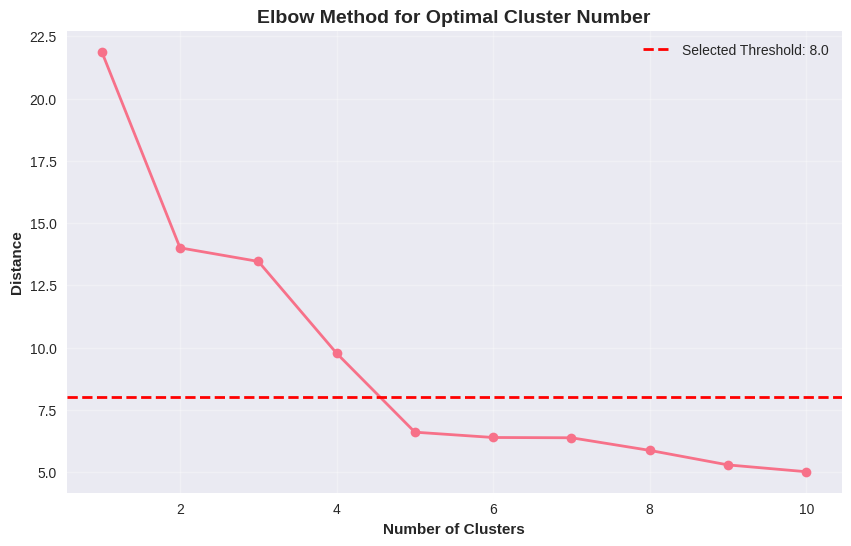


CLUSTER DISTRIBUTION (5 clusters):
  Cluster 1: 15 community areas (488,496 total crimes)
  Cluster 2: 20 community areas (222,643 total crimes)
  Cluster 3: 20 community areas (208,718 total crimes)
  Cluster 4: 16 community areas (140,031 total crimes)
  Cluster 5: 6 community areas (237,669 total crimes)

CLUSTER CHARACTERISTICS:

 CLUSTER 1 (15 areas):
   Average crimes: 32,566
   Dominant crime: BATTERY (21.7%)
   Arrest rate: 17.27%
   Weekend crime rate: 29.27%
  Domestic violence rate: 26.02%
   Highest crime communities:
      AUSTIN: 67,964 crimes
      SOUTH SHORE: 45,213 crimes
      NORTH LAWNDALE: 36,910 crimes

 CLUSTER 2 (20 areas):
   Average crimes: 11,132
   Dominant crime: THEFT (21.4%)
   Arrest rate: 11.43%
   Weekend crime rate: 29.21%
  Domestic violence rate: 18.26%
   Highest crime communities:
      BELMONT CRAGIN: 23,782 crimes
      ROGERS PARK: 20,844 crimes
      WEST RIDGE: 18,766 crimes

 CLUSTER 3 (20 areas):
   Average crimes: 10,436
   Dominant crim

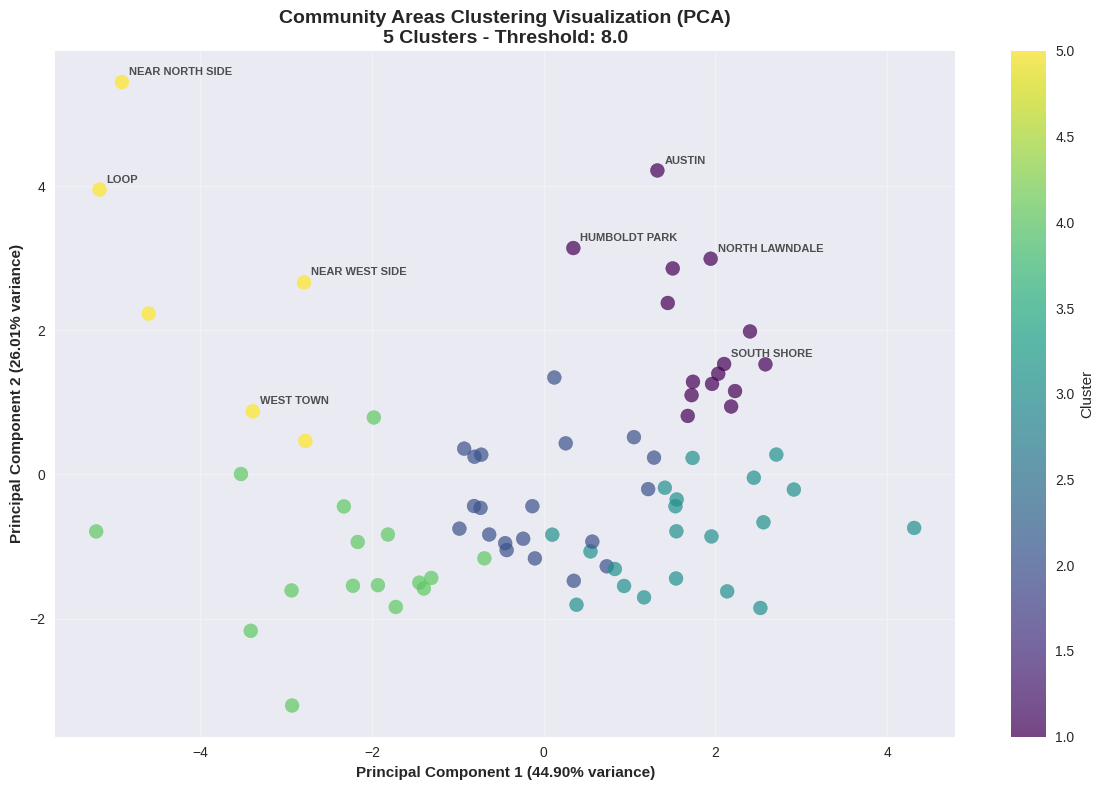

In [ ]:
#  Cluster Analysis and Interpretation
print("\n" + "="*70)
print("CLUSTER ANALYSIS AND INTERPRETATION")
print("="*70)

# Determine optimal number of clusters using elbow method
last_10 = Z[-10:, 2]  # Last 10 distances
last_10_rev = last_10[::-1]  # Reverse to show increasing distances
idxs = np.arange(1, len(last_10) + 1)

plt.figure(figsize=(10, 6))
plt.plot(idxs, last_10_rev, marker='o', linewidth=2)
plt.axhline(y=optimal_threshold, color='red', linestyle='--', linewidth=2,
           label=f'Selected Threshold: {optimal_threshold:.1f}')
plt.title('Elbow Method for Optimal Cluster Number', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters', fontweight='bold')
plt.ylabel('Distance', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nCLUSTER DISTRIBUTION ({unique_clusters} clusters):")
cluster_counts = clustering_df['cluster'].value_counts().sort_index()
for cluster_num, count in cluster_counts.items():
    total_crimes = clustering_df[clustering_df['cluster'] == cluster_num]['total_crimes'].sum()
    print(f"  Cluster {cluster_num}: {count} community areas ({total_crimes:,} total crimes)")

# Analyze cluster characteristics
print("\nCLUSTER CHARACTERISTICS:")
cluster_means = clustering_df.groupby('cluster')[features].mean()

for cluster_num in range(1, unique_clusters + 1):
    cluster_data = clustering_df[clustering_df['cluster'] == cluster_num]
    print(f"\n CLUSTER {cluster_num} ({len(cluster_data)} areas):")

    # Top features for this cluster
    cluster_mean = cluster_means.loc[cluster_num]

    print(f"   Average crimes: {cluster_mean['total_crimes']:,.0f}")

    # Find dominant crime type
    crime_rates = {
        'THEFT': cluster_mean['theft_rate'],
        'BATTERY': cluster_mean['battery_rate'],
        'CRIMINAL DAMAGE': cluster_mean['criminal_damage_rate'],
        'ASSAULT': cluster_mean['assault_rate'],
        'MOTOR VEHICLE THEFT': cluster_mean['motor_vehicle_theft_rate']
    }
    dominant_crime = max(crime_rates, key=crime_rates.get)
    print(f"   Dominant crime: {dominant_crime} ({crime_rates[dominant_crime]:.1%})")

    print(f"   Arrest rate: {cluster_mean['arrest_rate']:.2%}")
    print(f"   Weekend crime rate: {cluster_mean['weekend_rate']:.2%}")
    print(f"  Domestic violence rate: {cluster_mean['domestic_rate']:.2%}")

    # List top 3 communities by crime volume in this cluster
    top_communities = cluster_data.nlargest(3, 'total_crimes')[['community', 'total_crimes']]
    print(f"   Highest crime communities:")
    for _, row in top_communities.iterrows():
        print(f"      {row['community']}: {row['total_crimes']:,} crimes")

# Visualize clusters on a scatter plot (using PCA for 2D representation)
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)
clustering_df['pca1'] = principal_components[:, 0]
clustering_df['pca2'] = principal_components[:, 1]

plt.figure(figsize=(12, 8))
scatter = plt.scatter(clustering_df['pca1'], clustering_df['pca2'],
                     c=clustering_df['cluster'], cmap='viridis', s=100, alpha=0.7)

# Add labels for some points (top 10% by crime volume)
high_crime_threshold = clustering_df['total_crimes'].quantile(0.90)
for i, row in clustering_df.iterrows():
    if row['total_crimes'] > high_crime_threshold:
        plt.annotate(row['community'],
                    (row['pca1'], row['pca2']),
                    xytext=(5, 5),
                    textcoords='offset points',
                    fontsize=8,
                    alpha=0.8,
                    fontweight='bold')

plt.colorbar(scatter, label='Cluster')
plt.title(f'Community Areas Clustering Visualization (PCA)\n{unique_clusters} Clusters - Threshold: {optimal_threshold:.1f}',
          fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontweight='bold')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [ ]:
#  Strategic Recommendations Based on Cluster Analysis
print("\n" + "="*70)
print("STRATEGIC RECOMMENDATIONS BASED ON CLUSTER ANALYSIS")
print("="*70)

# Generate cluster profiles and recommendations
cluster_profiles = {}

for cluster_num in range(1, unique_clusters + 1):
    cluster_data = clustering_df[clustering_df['cluster'] == cluster_num]
    cluster_mean = cluster_means.loc[cluster_num]

    # Determine cluster type based on characteristics
    if cluster_mean['total_crimes'] > clustering_df['total_crimes'].mean():
        if cluster_mean['battery_rate'] > 0.2:
            profile_type = "HIGH CRIME - VIOLENT"
        elif cluster_mean['theft_rate'] > 0.25:
            profile_type = "HIGH CRIME - PROPERTY"
        else:
            profile_type = "HIGH CRIME - MIXED"
    else:
        if cluster_mean['total_crimes'] < clustering_df['total_crimes'].quantile(0.25):
            profile_type = "LOW CRIME - PREVENTIVE"
        else:
            profile_type = "MODERATE CRIME - MIXED"

    cluster_profiles[cluster_num] = profile_type

# Generate recommendations for each cluster type
cluster_recommendations = {
    "LOW CRIME - PREVENTIVE": [
        "Focus on community policing and crime prevention programs",
        "Maintain neighborhood watch programs",
        "Invest in community development initiatives"
    ],
    "MODERATE CRIME - MIXED": [
        "Balanced approach with targeted interventions",
        "Hotspot policing in specific areas",
        "Community engagement programs"
    ],
    "HIGH CRIME - VIOLENT": [
        "Intensive policing and violence intervention programs",
        "Deploy violence interruption teams",
        "Increase patrols in evening hours",
        "Implement community outreach programs"
    ],
    "HIGH CRIME - PROPERTY": [
        "Focus on theft and property crime prevention",
        "Enhance surveillance in commercial areas",
        "Community watch programs",
        "Target harden vulnerable properties"
    ],
    "HIGH CRIME - MIXED": [
        "Comprehensive crime reduction strategy",
        "Combine enforcement and prevention",
        "Data-driven resource allocation"
    ]
}

print("\n CLUSTER-BASED STRATEGIES:")
for cluster_num in range(1, unique_clusters + 1):
    cluster_areas = clustering_df[clustering_df['cluster'] == cluster_num]
    cluster_profile = cluster_profiles[cluster_num]

    print(f"\n CLUSTER {cluster_num}: {cluster_profile}")
    print(f"   Profile: {len(cluster_areas)} community areas, {cluster_areas['total_crimes'].sum():,} total crimes")
    print(f"   Key characteristics:")

    # Identify dominant features
    cluster_mean = cluster_means.loc[cluster_num]
    if cluster_mean['battery_rate'] > 0.2:
        print(f"   • High violent crime area (battery: {cluster_mean['battery_rate']:.1%})")
    if cluster_mean['theft_rate'] > 0.25:
        print(f"   • High property crime area (theft: {cluster_mean['theft_rate']:.1%})")
    if cluster_mean['weekend_rate'] > 0.35:
        print(f"   • Weekend crime hotspot ({cluster_mean['weekend_rate']:.1%} on weekends)")
    if cluster_mean['domestic_rate'] > 0.15:
        print(f"   • Domestic violence concerns ({cluster_mean['domestic_rate']:.1%} domestic incidents)")

    print(f"   Recommended actions:")
    for i, recommendation in enumerate(cluster_recommendations[cluster_profile], 1):
        print(f"   {i}. {recommendation}")

print(f"\n STRATEGIC INSIGHTS:")
high_crime_clusters = [k for k, v in cluster_profiles.items() if "HIGH CRIME" in v]
moderate_crime_clusters = [k for k, v in cluster_profiles.items() if "MODERATE" in v]
low_crime_clusters = [k for k, v in cluster_profiles.items() if "LOW CRIME" in v]

print(f"• {len(high_crime_clusters)} high-crime clusters need immediate intervention")
print(f"• {len(moderate_crime_clusters)} moderate-crime clusters require targeted approaches")
print(f"• {len(low_crime_clusters)} low-crime clusters can serve as best practice models")
print(f"• Resource allocation should prioritize clusters: {high_crime_clusters}")




STRATEGIC RECOMMENDATIONS BASED ON CLUSTER ANALYSIS

🎯 CLUSTER-BASED STRATEGIES:

🔹 CLUSTER 1: HIGH CRIME - VIOLENT
   Profile: 15 community areas, 488,496 total crimes
   Key characteristics:
   • High violent crime area (battery: 21.7%)
   • Domestic violence concerns (26.0% domestic incidents)
   Recommended actions:
   1. Intensive policing and violence intervention programs
   2. Deploy violence interruption teams
   3. Increase patrols in evening hours
   4. Implement community outreach programs

🔹 CLUSTER 2: MODERATE CRIME - MIXED
   Profile: 20 community areas, 222,643 total crimes
   Key characteristics:
   • Domestic violence concerns (18.3% domestic incidents)
   Recommended actions:
   1. Balanced approach with targeted interventions
   2. Hotspot policing in specific areas
   3. Community engagement programs

🔹 CLUSTER 3: MODERATE CRIME - MIXED
   Profile: 20 community areas, 208,718 total crimes
   Key characteristics:
   • Domestic violence concerns (25.1% domestic inci